In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

In [2]:
# Fetch the data.
df = pd.read_csv("https://ourworldindata.org/grapher/children-born-per-woman.csv?v=1&csvType=full&useColumnShortNames=true", storage_options = {'User-Agent': 'Our World In Data data fetch/1.0'})

# Fetch the metadata
metadata = requests.get("https://ourworldindata.org/grapher/children-born-per-woman.metadata.json?v=1&csvType=full&useColumnShortNames=true").json()

In [3]:
df.head(3)

,entity,code,year,fertility_rate_hist
0,Afghanistan,AFG,1950,7.248
1,Afghanistan,AFG,1951,7.260
2,Afghanistan,AFG,1952,7.260


In [4]:
mexico = df[df["entity"] == "Mexico"]

In [5]:
japon = df[df["entity"]=="Japan"]

In [6]:
anios_mexico = mexico["year"].to_numpy()
tasa_mexico = mexico["fertility_rate_hist"].to_numpy()

anios_japon = japon["year"].to_numpy()
tasa_japon = japon["fertility_rate_hist"].to_numpy()

In [7]:
type(anios_mexico)
type(anios_japon)

numpy.ndarray

In [8]:
df["entity"]

0        Afghanistan
1        Afghanistan
2        Afghanistan
3        Afghanistan
4        Afghanistan
            ...     
19397       Zimbabwe
19398       Zimbabwe
19399       Zimbabwe
19400       Zimbabwe
19401       Zimbabwe
Name: entity, Length: 19402, dtype: str

In [9]:
promedio_mexico = np.mean(tasa_mexico)
maximo_mexico = np.max(tasa_mexico)

minimo_mexico = np.min(tasa_mexico)
desviacion_mexico = np.std(tasa_mexico)

promedio_japon = np.mean(tasa_japon)
maximo_japon = np.max(tasa_japon)

minimo_japon = np.min(tasa_japon)
desviacion_japon = np.std(tasa_japon)



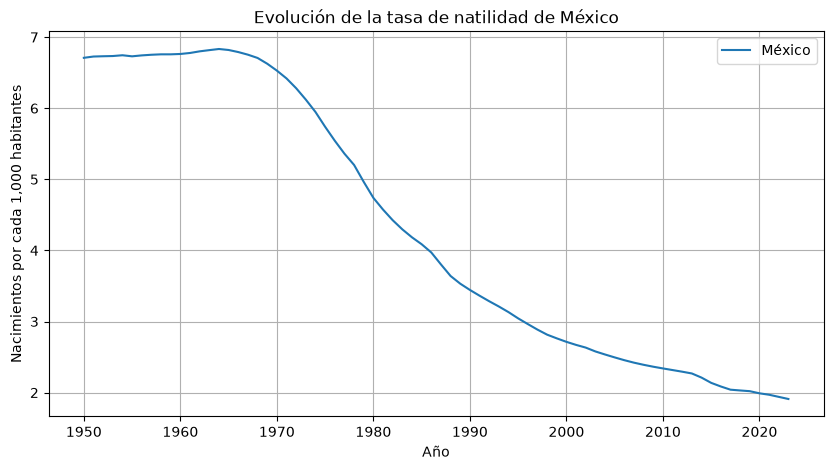

In [10]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.title("Evolución de la tasa de natilidad de México")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()

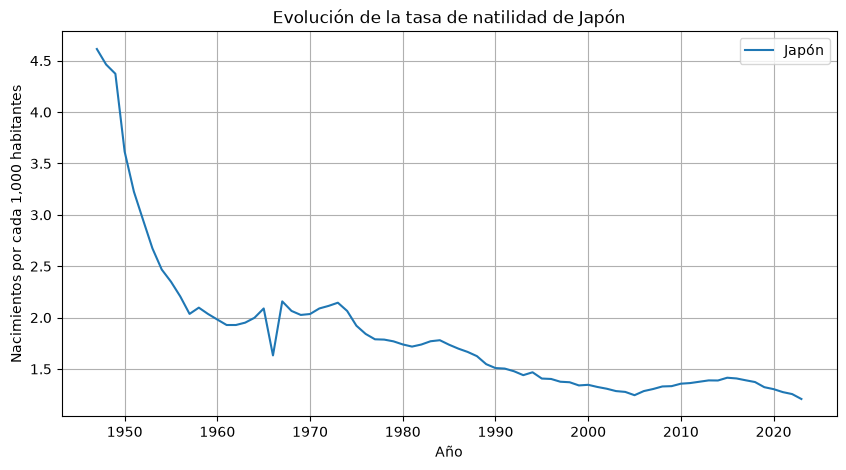

In [11]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.title("Evolución de la tasa de natilidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()



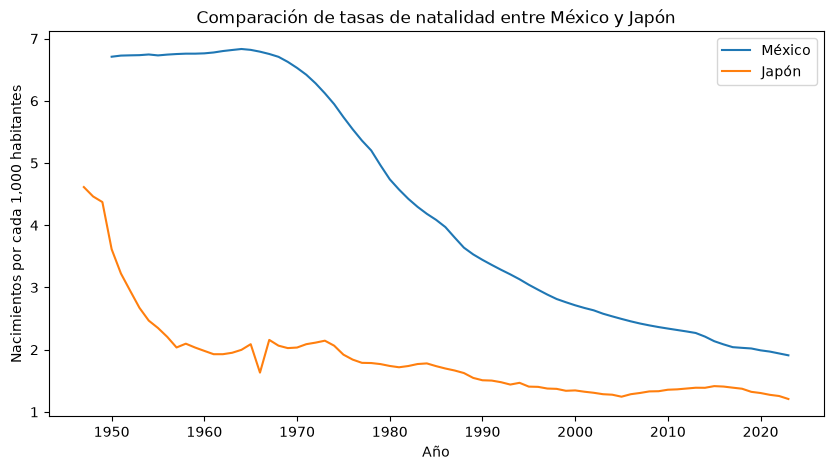

In [12]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")

plt.title('Comparación de tasas de natalidad entre México y Japón')
plt.legend()
plt.show()



In [13]:
#Filtro de indexación booleana o máscara
mascara_coincidencia_anios = anios_japon >= anios_mexico.min()
mascara_coincidencia_anios



array([False, False, False,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True])

In [14]:
tasa_japon = tasa_japon[mascara_coincidencia_anios]

In [15]:
anios_japon = anios_japon[mascara_coincidencia_anios]

In [16]:
anios_japon.shape

(74,)

In [18]:
diferencia_mx_jp = tasa_mexico - tasa_japon



In [19]:
anios_mexico

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [20]:
anios_japon

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

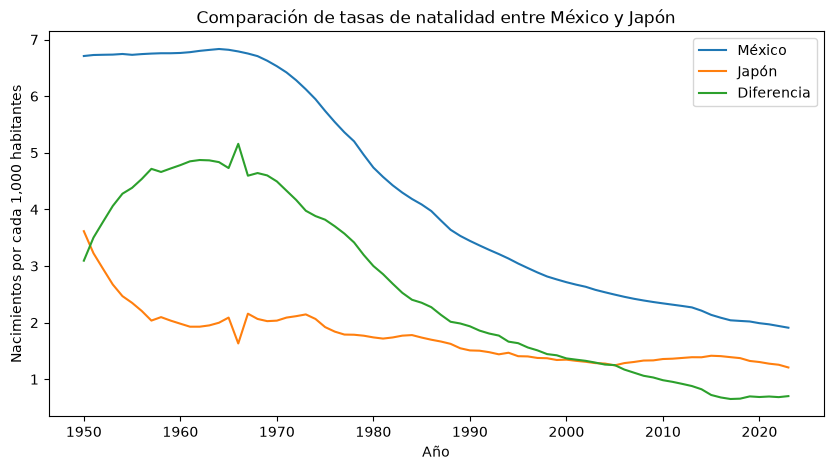

In [21]:
plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_japon,
    tasa_japon,
    label="Japón"
)

plt.plot(
    anios_mexico,
    diferencia_mx_jp,
    label="Diferencia"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")

plt.title('Comparación de tasas de natalidad entre México y Japón')
plt.legend()
plt.show()

In [22]:
brasil = df[df["entity"]=="Brazil"]
anios_brasil = brasil["year"].to_numpy()
tasa_brasil = brasil["fertility_rate_hist"].to_numpy()

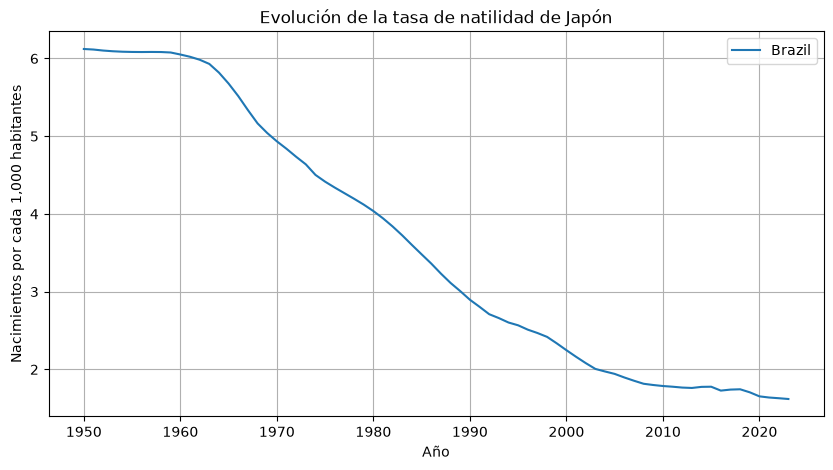

In [23]:
plt.figure(figsize=(10,5))
plt.plot(
    anios_brasil,
    tasa_brasil,
    label="Brazil"
)

plt.title("Evolución de la tasa de natilidad de Japón")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")
plt.grid(True)
plt.legend()



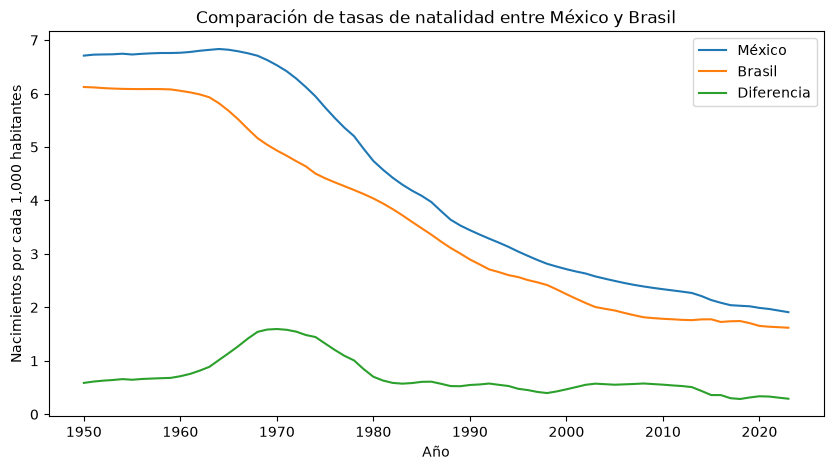

In [24]:
diferencia_mx_br = tasa_mexico - tasa_brasil

plt.figure(figsize=(10,5))

plt.plot(
    anios_mexico,
    tasa_mexico,
    label="México"
)

plt.plot(
    anios_brasil,
    tasa_brasil,
    label="Brasil"
)

plt.plot(
    anios_mexico,
    diferencia_mx_br,
    label="Diferencia"
)

plt.title("Comparación de la tasa de natalidad")
plt.xlabel("Año")
plt.ylabel("Nacimientos por cada 1,000 habitantes")

plt.title('Comparación de tasas de natalidad entre México y Brasil')
plt.legend()
plt.show()

In [25]:
anios_comunes = np.intersect1d(
    anios_mexico,
    anios_japon
)

In [26]:
anios_comunes

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

In [27]:
#Otra forma de filtrar es con merge de pandas
comparacion_mexico_japon = pd.merge(
    mexico[["year", "fertility_rate_hist"]],
    japon[["year", "fertility_rate_hist"]],
    on="year",
    suffixes=("_mexico", "_japon")
)


In [28]:
comparacion_mexico_japon.head(3)

,year,fertility_rate_hist_mexico,fertility_rate_hist_japon
0,1950,6.709,3.615
1,1951,6.727,3.225
2,1952,6.731,2.947


In [29]:
mexico_anios_comunes = mexico[mexico["year"].isin(anios_comunes)]
japon_anios_comunes = japon[japon["year"].isin(anios_comunes)]



In [30]:
mexico_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].isin(anios_comunes)
japon_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].isin(anios_comunes)

In [31]:
anios_japon = np.delete(anios_japon, [23,25,30,42,48])

In [32]:
plt.figure(figsize=(10,5))

<Figure size 1000x500 with 0 Axes>

<Figure size 1000x500 with 0 Axes>

In [33]:
mex_anios_comunes = mexico_anios_comunes["year"].to_numpy()
jpn_anios_comunes = japon_anios_comunes["year"].to_numpy()

mex_tasa_comunes = mexico_anios_comunes["fertility_rate_hist"].to_numpy()
jpn_tasa_comunes = japon_anios_comunes["fertility_rate_hist"].to_numpy()